<a href="https://colab.research.google.com/github/ewst22ParkSY/ESAA11_PSY/blob/ESAA11_OB/ESAA_OB_WEEK2_2_transcript.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 5. 부스팅 boosting

- 약한 학습기를 여러 개 연결하여 강한 학습기를 만드는 앗아블 방법
- 앞의 모델을 보완해나가며 일련의 예측기를 학습

인기있는 것: 에이다 부스트(AdaBoost - adaptive boosting)와 그라디언트 부스팅(Gradient Bossting)

### 5.1 에이다부스트
- 과소적합했던 훈련 샘플의 가중치를 더 높이는 것
> 어려운 샘플에 점점 더 맞춰짐.

- 샘플의 가중치를 업데이트하며 순차적으로 학습하는 에이다 부스트 시각화(하단) <br>
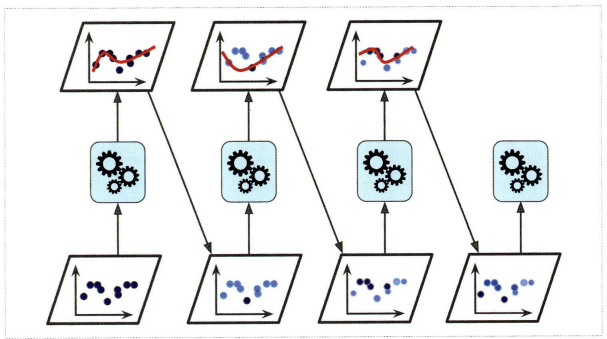


연속된 학습 기법 > 경사하강법과 비슷함

경사하강법: 비용 함수를 최소화하기 위해 한 예측기의 모델 파라미터를 조정
<br>
에이다 부스트: 앙상블에 예측기를 추가

단점: 각 예측기가 병렬화(혹은 분할) 불가능. > 배깅이나 페이스팅만큼 확장성이 높지 않음.

예측기가 정확할수록 가중치가 높아짐. if 무작위로 예측하는 정도라면 가중치가 0에 가까움. 그보다 나쁘면 가중치는 음수.

#### 사이킷런에서
- SAMME라는 에이다부스트의 다중 클레스 버전을 사용함.
- 클래스가 두 개 뿐일 때는 SAMME가 에이다부스트와 동일
- 클래스의 확률을 추정할 수 있을 경우 SAMME.R가 SAMME보다 성능이 더 좋음.

In [8]:
# 필사 전 코드
import warnings
warnings.filterwarnings('ignore')

# import package
import numpy as np
import os


#5장에서 소개한 moons dataset 불러오기
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
X,y = make_moons(n_samples=100, noise=0.15)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [11]:
# 에이다부스트 분류기 훈련

from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

ada_clf = AdaBoostClassifier(
    DecisionTreeClassifier(max_depth=1), n_estimators=200,
    algorithm="SAMME", learning_rate=0.5)

ada_clf.fit(X_train, y_train)

AdaBoostClassifier(algorithm='SAMME',
                   estimator=DecisionTreeClassifier(max_depth=1),
                   learning_rate=0.5, n_estimators=200)

### 5.2 그레이디언트 부스팅 gradient boosting

- 앙상블에 이전까지의 오차를 보정하도록 예측기를 순차적으로 추가
> 다른 점: 샘플의 가중치를 수정X, 이전 예측기가 만든 잔여 오차residual error에 새로운 예측기 학습

결정트리를 기반 예측기로 사용하는 회귀 > 그레이디언트 트리 부스팅 or 그레이디언트 부스티드 회귀 트리

문제 예시


In [12]:
#결정트리회귀를 훈련세트에 학습

from sklearn.tree import DecisionTreeRegressor

tree_reg1 = DecisionTreeRegressor(max_depth=2)
tree_reg1.fit(X, y)

DecisionTreeRegressor(max_depth=2)

In [13]:
# 첫 번째 예측기에서 생긴 잔여 오차에 두 번째 DecisionTreeRegressor를 훈련

y2 = y - tree_reg1.predict(X)
tree_reg2 = DecisionTreeRegressor(max_depth=2)
tree_reg2.fit(X, y2)

DecisionTreeRegressor(max_depth=2)

In [14]:
# 두 번째 예측기가 만든 잔여 오차에 세 번째 회귀 모델 훈련

y3 = y2 - tree_reg2.predict(X)
tree_reg3 = DecisionTreeRegressor(max_depth=2)
tree_reg3.fit(X, y3)

# 세 개의 트리를 포함하는 앙상블 모델이 생김.
# 새로운 샘플에 대한 예측을 만들려면 모든 트리의 예측을 더하면 됨!

# y_pred = sum(tree.predict(X_new) for tree in (tree_reg1, tree_reg2, tree_reg3))

DecisionTreeRegressor(max_depth=2)

- 지금 한 과정을 사이킷런의 ```GradientBosstingRegressor```를 사용하면 GPRT 앙상블을 간단하게 훈련시킬 수 있음.
- 트리수(n_estimator)와 같이 앙상블 훈련을 제어하는 매개변수, RandomForestRegressor와 비슷하게 결정트리의 성장을 제어하는 매개변수(**max_depth, min_samples_leaf**)를 가지고 있음.

In [16]:
from sklearn.ensemble import GradientBoostingRegressor

gbrt = GradientBoostingRegressor(max_depth=2, n_estimators=3, learning_rate=1.0)
gbrt.fit(X, y)

GradientBoostingRegressor(learning_rate=1.0, max_depth=2, n_estimators=3)

- learning_rate: 각 트리의 기여 정도를 조정
> if 낮게 설정할 시: 앙상블을 훈련 세트에 학습시키기 위해 많은 트리가 필요 but 일반적으로 예측 성능이 좋아짐 > 축소shrinkage

- 최적의 트리 수 찾는 방법: 조기 종료 기법 사용
> 간단하게 구현: staged_predict() 메서드
>> 훈련의 각 단계에서 앙상블에 의해 만들어진 예측기를 순회하는 반복자iterator를 반환

In [19]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

X_train, X_val, y_train, y_val = train_test_split(X, y)

gbrt = GradientBoostingRegressor(max_depth=2, n_estimators=120)
gbrt.fit(X_train, y_train)

errors = [mean_squared_error(y_val, y_pred)
          for y_pred in gbrt.staged_predict(X_val)]
bst_n_estimators = np.argmin(errors) + 1

gbrt_best = GradientBoostingRegressor(max_depth=2, n_estimators=bst_n_estimators)
gbrt_best.fit(X_train, y_train)

GradientBoostingRegressor(max_depth=2, n_estimators=119)

``` warm_start=True```로 설정하면 사이킷런이 fit() 메서드가 호출될 때 기존 트리를 유지하고 훈련을 추가할 수 있도록 해줌.


In [22]:
# 다섯 번의 반복 동안 검증 오차가 향상되지 않으면 훈련을 멈춤.

gbrt = GradientBoostingRegressor(max_depth=2, warm_start=True)

min_val_error = float("inf")
error_going_up = 0
for n_estimators in range(1, 120):
  gbrt.n_estimatsors = n_estimators
  gbrt.fit(X_train, y_train)
  y_pred = gbrt.predict(X_val)
  val_error = mean_squared_error(y_val, y_pred)
  if val_error < min_val_error:
    min_val_error = val_error
    error_going_up = 0
  else:
    error_going_up += 1
    if error_going_up == 5:
      break # 조기 종료

GradientBossintgRegressor는 각 트리가 훈련할 때 사용할 훈련 샘플의 비율을 지정할 수 있는 subsample 매개변수도 지원함. <br>

**확률적 그레이디언트 부스팅** stochastic gradient boosting<br>
subsample=0.25일 경우 각 트리는 무작위로 선택된 25%의 훈련 샘플로 학습됨.
> 편향이 높아지는 대신 분산이 낮아지게 됨. 훈련 속도를 상당히 높임.

- 그레이디언트 부스팅에 다른 비용함수를 사용할 수도 있음. loss 매개변수를 이용해 지정.

최적화된 그레이디언트 부스팅 구현으로 XGBoost 파이썬 라이브러리가 유명.

In [28]:
import xgboost

xgb_reg = xgboost.XGBRegressor()
xgb_reg.fit(X_train, y_train)
y_pred = xgb_reg.predict(X_val)

In [29]:
xgb_reg = xgboost.XGBRegressor(early_stopping_rounds = 2)
xgb_reg.fit(X_train, y_train,
            eval_set=[(X_val, y_val)])
y_pred = xgb_reg.predict(X_val)

[0]	validation_0-rmse:0.38837
[1]	validation_0-rmse:0.30830
[2]	validation_0-rmse:0.26973
[3]	validation_0-rmse:0.24206
[4]	validation_0-rmse:0.23436
[5]	validation_0-rmse:0.23350
[6]	validation_0-rmse:0.23491


## 6. 스태킹 Stacking

여러 예측기가 각각 다른 값을 예측하고 마지막 예측기(블렌더blender 또는 메타 학습기 meta learner)가 예측을 입력으로 받아 최종 예측을 만듦.

블렌더를 학습시키는 일반적인 방법: 홀드 아웃hold-out 세트를 사용하는 것.

블렌더 훈련 시각화<br>
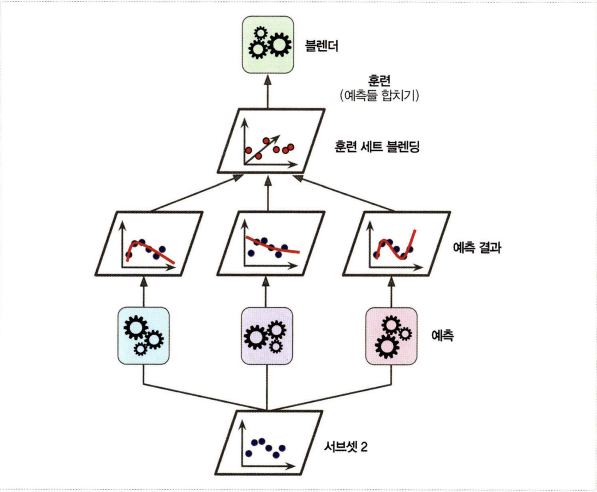